In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess
import barycenter_functions

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [2]:
# Useful references -------------------------
familiar_group_ids = ["baggy", "bash", "boned", "cargo","five", "grip", "mule", "polio", "rerun", "slate", "slept", "trial", "yeast"] 
unfamiliar_group_ids = ["atom", "brim", "chef", "clerk", "debt", "grid", "lens", "limb", "most","slimy", "swarm", "wok"]
track_pieces_of_interest = ['symmetric_parabolic','t_turn'] # track segments for trial 10 analysis
#track_piece_id = 'symmetric_parabolic'

In [3]:
# Get objects associated with a given subject and their trial
subject_object = subject_dict["baggy"] 
trial_object_ten = subject_object.trials[9]

# Get track objects for later functions...
sym_parab_object = trial_object_ten.pieces['symmetric_parabolic'] # get the track piece object associated to the track piece
t_turn_object = trial_object_ten.pieces['t_turn'] # get the track piece object associated to the track piece

In [4]:
# get trajectories (trimmed for RESETS) for both track segments
sym_parab_familiar_trajectories,sym_parab_unfamiliar_trajectories = barycenter_functions.process_groups(familiar_group_ids,unfamiliar_group_ids,subject_dict, 'symmetric_parabolic')
t_turn_familiar_trajectories,t_turn_unfamiliar_trajectories = barycenter_functions.process_groups(familiar_group_ids,unfamiliar_group_ids,subject_dict, 't_turn')

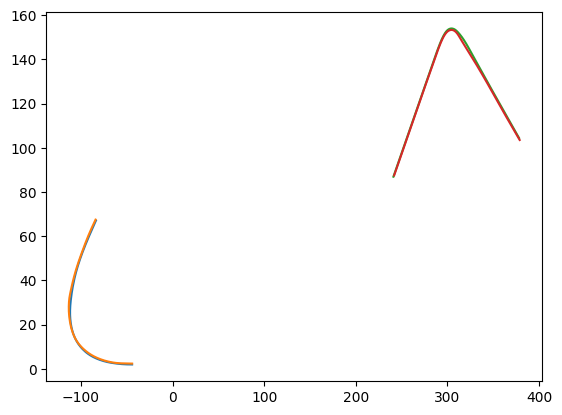

In [5]:
barycenter_functions.get_barycenter_per_group("Constant Track",sym_parab_object,sym_parab_familiar_trajectories,familiar_group_ids)
barycenter_functions.get_barycenter_per_group("Variable Track",sym_parab_object,sym_parab_unfamiliar_trajectories,unfamiliar_group_ids)
barycenter_functions.get_barycenter_per_group("Constant Track",t_turn_object,t_turn_familiar_trajectories,familiar_group_ids)
barycenter_functions.get_barycenter_per_group("Variable Track",t_turn_object,t_turn_unfamiliar_trajectories,unfamiliar_group_ids)

In [6]:
# # To visualize all trajectories... 
# barycenter_functions.plot_trajectories_for_group("Constant Track",sym_parab_familiar_trajectories,sym_parab_object)
# barycenter_functions.plot_trajectories_for_group("Variable Track",sym_parab_unfamiliar_trajectories,sym_parab_object)
# barycenter_functions.plot_trajectories_for_group("Constant Track",t_turn_familiar_trajectories,t_turn_object)
# barycenter_functions.plot_trajectories_for_group("Variable Track",t_turn_unfamiliar_trajectories,t_turn_object)